In [1]:
%load_ext autoreload
%autoreload 2

import os
os.getcwd()

'/output/cifar100-benchmark'

In [2]:
import torchvision
import torchvision.transforms as transforms
import torch
from torch.utils.data import random_split

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# 加载完整训练集
full_trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)

# 将训练集按8:2比例分割为训练集和验证集
train_size = int(0.8 * len(full_trainset))
val_size = len(full_trainset) - train_size
trainset, valset = random_split(full_trainset, [train_size, val_size])

train_loader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(valset, batch_size=4, shuffle=False)

# 测试集保持不变
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(testset, batch_size=4, shuffle=False)


Files already downloaded and verified
Files already downloaded and verified


In [3]:
from networks import CNN
from utils import check_model


device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = CNN().to(device)
check_model(model, num_classes=100, batch_size=4, device=device)



device: cuda:0
batch_size: 4
num_classes: 100
Forward pass output shape: torch.Size([4, 100])
test_target shape: torch.Size([4])
Test loss: 4.5802
损失计算成功


In [4]:
from utils import train_model

model = CNN(num_classes=100, in_channels=3, dropout=0.5).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_epochs = 2


In [9]:
train_model(
    model,
    train_loader,
    val_loader,
    test_loader,
    optimizer,
    criterion,
    device,
    num_epochs,
    save_dir="logs/CNN",
    save_log=True,
    pretrained="/output/cifar100-benchmark/logs/CNN/log_4/best_model_top1:0.5055_in_epoch1.pth"
)

print("Training complete")

加载预训练模型: /output/cifar100-benchmark/logs/CNN/log_4/best_model_top1:0.5055_in_epoch1.pth
日志和模型将保存到: logs/CNN/log_5
Epoch 1/2


Training:   0%|          | 6/1250 [00:00<00:21, 57.41it/s, loss=4, top 1=0.33, top 5=0.665]    

Train Loss: 2.5674, Top 1: 0.3318, Top 5: 0.6556
Val Loss: 2.0042, Top 1: 0.4971, Top 5: 0.8075
当前最佳top1准确率: 0.4971 in epoch 1
Epoch 2/2


Train Loss: 2.5487, Top 1: 0.3354, Top 5: 0.6596
Val Loss: 2.0504, Top 1: 0.4855, Top 5: 0.7943
加载最佳模型，进行测试


Testing: 100%|██████████| 2500/2500 [00:09<00:00, 268.64it/s, loss=2.33, top 1=0.404, top 5=0.722]


Test Loss: 2.3303, Top 1: 0.4043, Top 5: 0.7222
Training complete


In [10]:
from utils import predict

predict(model, 
        test_loader, 
        device, 
        pretrained=None)

 

Top 1 Accuracy: 0.4043, Top 5 Accuracy: 0.7222


(0.4043, 0.7222)

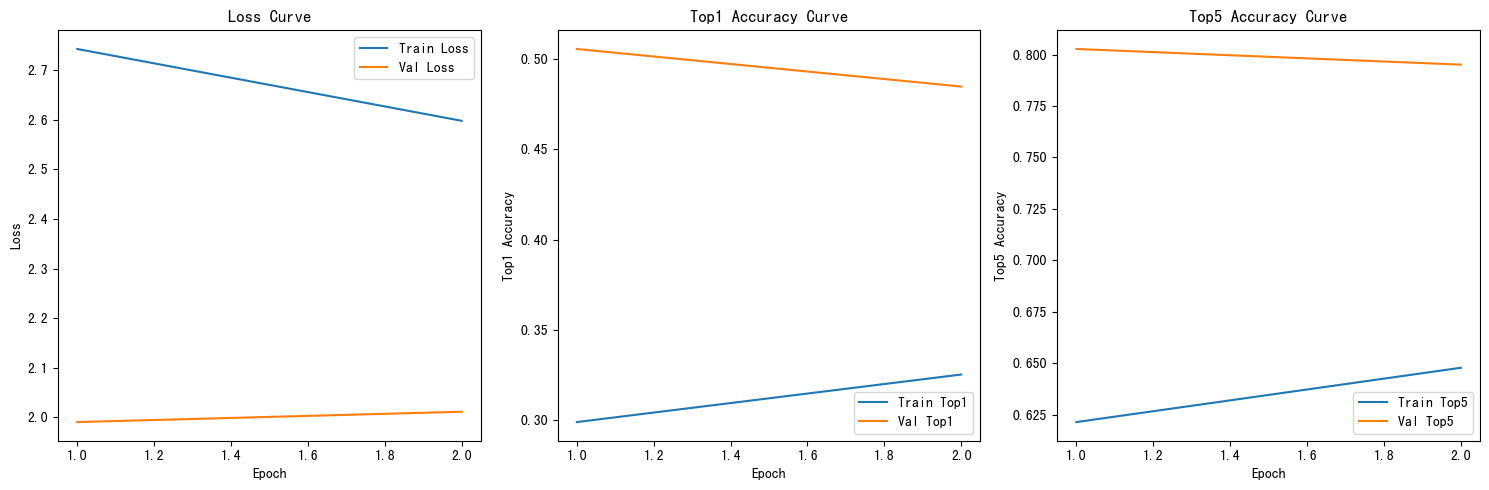

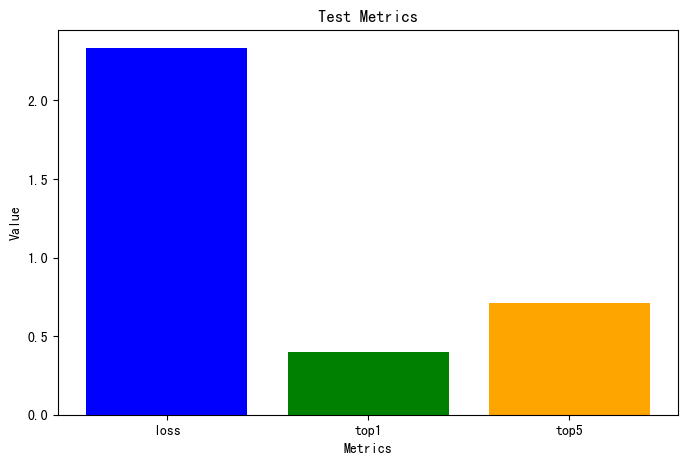

In [11]:
from utils import logshow

logshow('logs/CNN/log_4/training_log.json')